In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt     
import seaborn as sns
from sklearn.model_selection import train_test_split

In [121]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

# Read

In [122]:
import pandas as pd

df = pd.read_csv(r"D:\Portfolio\DA\Loan\Data_Raw\Loan_default.csv", encoding="utf-8-sig")

In [123]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan Date (DD/MM/YYYY)
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,10/15/2018
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,3/25/2016
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,11/11/2013
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,6/22/2017
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,6/9/2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0,10/7/2017
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1,1/1/2016
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0,3/5/2017
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0,4/5/2013


In [124]:
print(df.shape)
print(df.columns.tolist())

(255347, 19)
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default', 'Loan Date (DD/MM/YYYY)']


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   LoanID                  255347 non-null  object 
 1   Age                     255347 non-null  int64  
 2   Income                  255347 non-null  int64  
 3   LoanAmount              255347 non-null  int64  
 4   CreditScore             255347 non-null  int64  
 5   MonthsEmployed          255347 non-null  int64  
 6   NumCreditLines          255347 non-null  int64  
 7   InterestRate            255347 non-null  float64
 8   LoanTerm                255347 non-null  int64  
 9   DTIRatio                255347 non-null  float64
 10  Education               255347 non-null  object 
 11  EmploymentType          255347 non-null  object 
 12  MaritalStatus           255347 non-null  object 
 13  HasMortgage             255347 non-null  object 
 14  HasDependents       

In [126]:
df.isnull().sum()

LoanID                    0
Age                       0
Income                    0
LoanAmount                0
CreditScore               0
MonthsEmployed            0
NumCreditLines            0
InterestRate              0
LoanTerm                  0
DTIRatio                  0
Education                 0
EmploymentType            0
MaritalStatus             0
HasMortgage               0
HasDependents             0
LoanPurpose               0
HasCoSigner               0
Default                   0
Loan Date (DD/MM/YYYY)    0
dtype: int64

In [127]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [128]:
df['EmploymentType'].value_counts()

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

In [129]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

In [130]:
df['HasMortgage'].value_counts()

HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

In [131]:
df['HasDependents'].value_counts()

HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

In [132]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [133]:
df['HasCoSigner'].value_counts()

HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

In [134]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [135]:
df["EmploymentType"] = df["EmploymentType"].map({
    "Part-time": 0,
    "Unemployed": 1,
    "Self-employed": 2,
    "Full-time": 3
})

# Education
df["Education"] = df["Education"].map({
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
})

# MaritalStatus
df["MaritalStatus"] = df["MaritalStatus"].map({
    "Single": 0,
    "Married": 1,
    "Divorced": 2
})

# HasMortgage
df["HasMortgage"] = df["HasMortgage"].map({
    "No": 0,
    "Yes": 1
})

# HasDependents
df["HasDependents"] = df["HasDependents"].map({
    "No": 0,
    "Yes": 1
})

# LoanPurpose
df["LoanPurpose"] = df["LoanPurpose"].map({
    "Auto": 0,
    "Business": 1,
    "Education": 2,
    "Home": 3,
    "Other": 4
})

# HasCoSigner
df["HasCoSigner"] = df["HasCoSigner"].map({
    "No": 0,
    "Yes": 1
})

In [136]:
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Loan Date (DD/MM/YYYY)
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,1,3,2,1,1,4,1,0,10/15/2018
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,2,3,1,0,0,4,1,0,3/25/2016
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,2,1,2,1,1,0,0,1,11/11/2013
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,0,3,1,0,0,1,0,0,6/22/2017
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,1,1,2,0,1,0,0,0,6/9/2014


## Outlier detection

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

Column: Age
Number of outliers: 0

Column: Income
Number of outliers: 0

Column: LoanAmount
Number of outliers: 0

Column: CreditScore
Number of outliers: 0

Column: MonthsEmployed
Number of outliers: 0

Column: NumCreditLines
Number of outliers: 0

Column: InterestRate
Number of outliers: 0

Column: LoanTerm
Number of outliers: 0

Column: DTIRatio
Number of outliers: 0

Column: Education
Number of outliers: 0

Column: EmploymentType
Number of outliers: 0

Column: MaritalStatus
Number of outliers: 0

Column: HasMortgage
Number of outliers: 0

Column: HasDependents
Number of outliers: 0

Column: LoanPurpose
Number of outliers: 0

Column: HasCoSigner
Number of outliers: 0

Column: Default
Number of

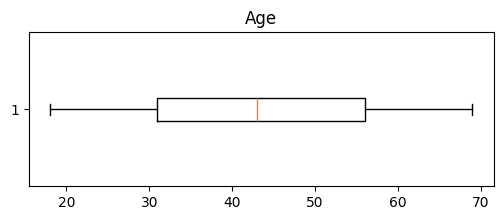

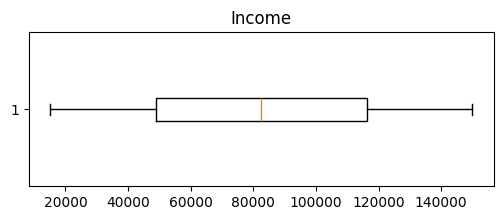

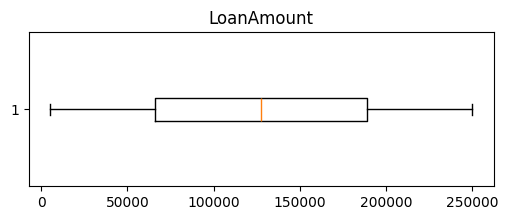

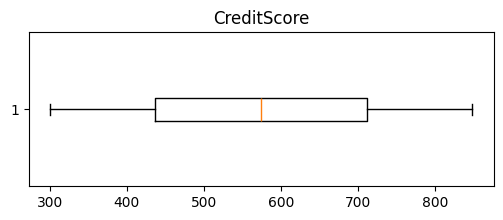

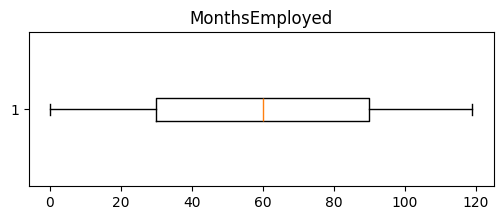

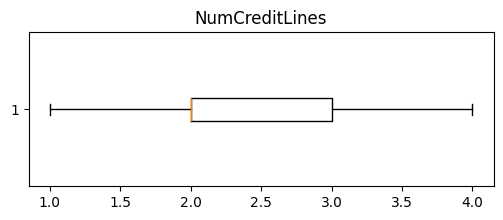

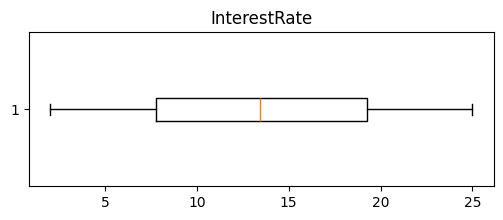

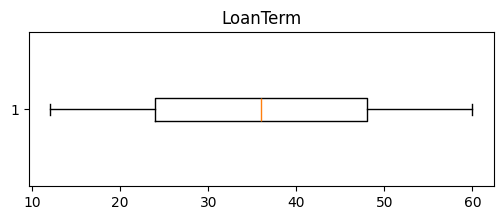

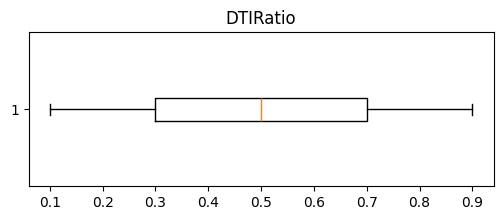

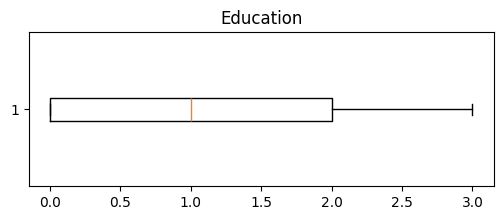

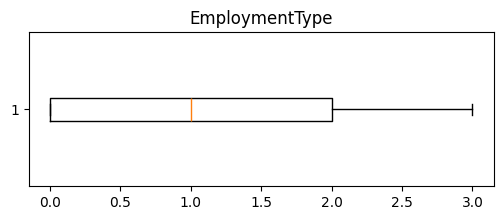

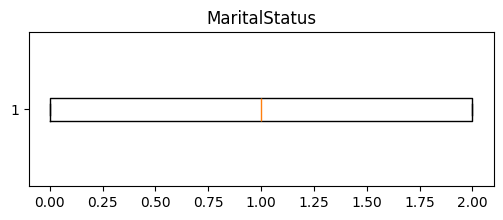

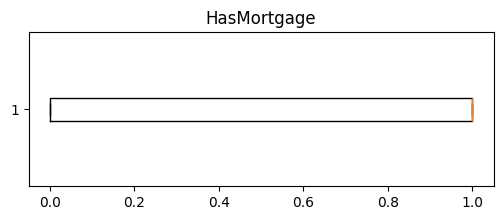

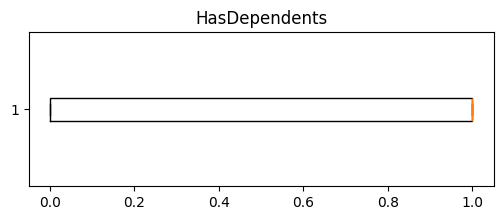

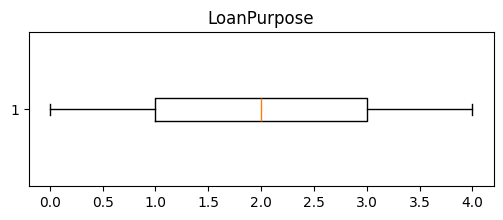

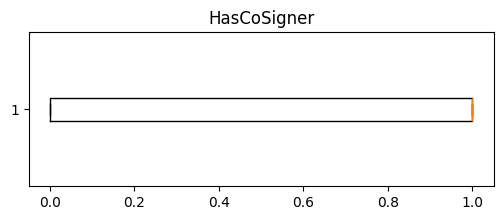

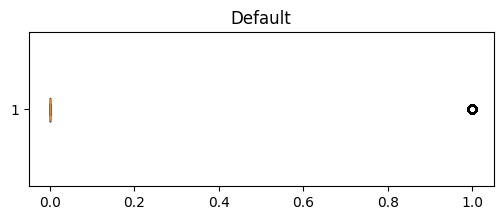

In [137]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\nColumn: {col}")
    print(f"Number of outliers: {len(outliers)}")

    Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

income_outliers = df[
    (df["Income"] < lower) |
    (df["Income"] > upper)
]

print(income_outliers.head())

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

# Default Prediction

In [138]:
loan_ids = df["LoanID"]
df.drop(columns=["LoanID", "Loan Date (DD/MM/YYYY)"], inplace=True)

In [139]:
# df["Loan Date (DD/MM/YYYY)"] = pd.to_datetime(
#     df["Loan Date (DD/MM/YYYY)"],
#     dayfirst=True
# )

# # Tách year/month
# df["Loan_Year"] = df["Loan Date (DD/MM/YYYY)"].dt.year
# df["Loan_Month"] = df["Loan Date (DD/MM/YYYY)"].dt.month

# # Drop original date column
# df.drop(columns=["Loan Date (DD/MM/YYYY)"], inplace=True)

In [140]:
X = df.drop(columns=["Default"])
y = df["Default"]

In [141]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [142]:
# LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, lr_pred))



Accuracy: 0.8854905032308596

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.60      0.03      0.05      5900

    accuracy                           0.89     51070
   macro avg       0.74      0.51      0.49     51070
weighted avg       0.85      0.89      0.84     51070


Confusion Matrix:
[[45067   103]
 [ 5745   155]]

ROC-AUC:
0.5119954559610961


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [143]:
# MODEL 2 — RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, rf_pred))

Accuracy: 0.8869590757783434

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.64      0.05      0.09      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070


Confusion Matrix:
[[45005   165]
 [ 5608   292]]

ROC-AUC:
0.52291932923832


In [144]:
# MODEL 3 — GRADIENT BOOSTING

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, gb_pred))

Accuracy: 0.8873311141570394

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.67      0.05      0.09      5900

    accuracy                           0.89     51070
   macro avg       0.78      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070


Confusion Matrix:
[[45022   148]
 [ 5606   294]]

ROC-AUC:
0.5232769987579877


# Predict

In [146]:
_, X_test_ids, _, y_test_ids = train_test_split(
    loan_ids,
    y,
    test_size=0.2,
    random_state=42
)

In [147]:
default_prob = gb_model.predict_proba(X_test)[:, 1]

# ============================================================
# CREATE RESULT TABLE
# ============================================================

result_df = pd.DataFrame({
    "LoanID": X_test_ids.values,
    "Actual_Default": y_test.values,
    "Default_Probability": default_prob
})

# ============================================================
# CLASSIFY RISK LEVEL
# ============================================================

def classify_risk(prob):

    if prob >= 0.7:
        return "High Risk"

    elif prob >= 0.4:
        return "Medium Risk"

    else:
        return "Low Risk"

result_df["Risk_Level"] = result_df[
    "Default_Probability"
].apply(classify_risk)

# ============================================================
# SORT BY HIGHEST RISK
# ============================================================

result_df = result_df.sort_values(
    by="Default_Probability",
    ascending=False
)

# ============================================================
# SHOW TOP HIGH-RISK LOANS
# ============================================================

print(result_df.head(20))

           LoanID  Actual_Default  Default_Probability Risk_Level
36886  XPT5KL7BRA               1             0.837660  High Risk
49553  7OLT65OP99               1             0.820605  High Risk
33735  L1O3DOQLOM               1             0.805097  High Risk
46581  7UJHCCVW6W               1             0.778799  High Risk
14405  DJYX75JY4B               1             0.778288  High Risk
4294   CHYO7KTM55               1             0.774704  High Risk
12188  HH0HFW25FQ               0             0.769988  High Risk
4969   9OZNF5GV5S               1             0.766632  High Risk
7602   IVR81WW2XV               1             0.764488  High Risk
22343  BWQGSJQP3P               1             0.764484  High Risk
20096  9YMISHD5SW               1             0.761007  High Risk
36521  0T81CORX1Y               1             0.743817  High Risk
46728  THRUPFAYSJ               1             0.742224  High Risk
5289   O124BBA347               1             0.732693  High Risk
1083   H2Y